In [1]:
!pip install pandas numpy matplotlib scikit-learn

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\phuta\Downloads\ML_Project\ml_project_env\Scripts\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("financial_fraud_detection_dataset(1).csv")

In [5]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash'],
      dtype='str')

In [6]:
df = df[["timestamp", "amount", "transaction_type"]]

In [7]:
df.columns = ["transaction_date", "amount", "transaction_type"]

In [8]:
df = df[["transaction_date", "amount", "transaction_type"]]

In [9]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="ISO8601")

In [10]:
df.head()

,transaction_date,amount,transaction_type
0,2023-08-22 09:22:43.516168,343.78,withdrawal
1,2023-08-04 01:58:02.606711,419.65,withdrawal
2,2023-05-12 11:39:33.742963,2773.86,deposit
3,2023-10-10 06:04:43.195112,1666.22,deposit
4,2023-09-24 08:09:02.700162,24.43,transfer


In [11]:
df["deposit_amount"] = df["amount"].where(
    df["transaction_type"] == "deposit", 0
)

df["withdrawal_amount"] = df["amount"].where(
    df["transaction_type"].isin(["withdrawal", "payment"]), 0
)

In [12]:
df.columns

Index(['transaction_date', 'amount', 'transaction_type', 'deposit_amount',
       'withdrawal_amount'],
      dtype='str')

In [13]:
df = df[["transaction_date", "deposit_amount", "withdrawal_amount"]]

In [14]:
df = df.set_index("transaction_date")

In [15]:
monthly_df = df.resample("h").sum()

monthly_df.head()

,deposit_amount,withdrawal_amount
transaction_date,,
2023-01-01 00:00:00,8620.73,1828.63
2023-01-01 01:00:00,11253.96,5568.79
2023-01-01 02:00:00,19905.36,6172.02
2023-01-01 03:00:00,33653.62,8744.73
2023-01-01 04:00:00,32357.57,11872.15


In [16]:
monthly_df["total_deposit"] = monthly_df["deposit_amount"]
monthly_df["total_withdrawal"] = monthly_df["withdrawal_amount"]

monthly_df["net_flow"] = (
    monthly_df["total_deposit"] - monthly_df["total_withdrawal"]
)

In [17]:
monthly_df = monthly_df.reset_index()
monthly_df.rename(columns={"transaction_date": "date"}, inplace=True)

In [18]:
inflation = pd.read_csv("inflation.csv", skiprows=4)

In [19]:
inflation = inflation.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="inflation_rate"
)

In [20]:
inflation = inflation[inflation["Country Name"] == "India"]

In [21]:
monthly_df.head()

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42


In [22]:
monthly_df.shape

(8783, 6)

In [23]:
year_cols = [col for col in inflation.columns if col.isdigit()]

In [24]:
inflation = inflation[["Country Name"] + year_cols]

In [25]:
inflation = inflation.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="inflation_rate"
)

In [26]:
inflation["year"] = inflation["year"].astype(int)

In [27]:
inflation = inflation[inflation["Country Name"] == "India"]

In [28]:
inflation = inflation.dropna()

In [29]:
inflation = inflation[["year", "inflation_rate"]]

In [30]:
monthly_df["year"] = monthly_df["date"].dt.year

final_df = pd.merge(
    monthly_df,
    inflation[["year", "inflation_rate"]],
    on="year",
    how="left"
)

In [31]:
final_df.head()

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,NaN


In [32]:
interest = pd.read_csv("interrest_rate.csv", skiprows=4)

In [33]:
interest.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Deposit interest rate (%),FR.INR.DPST,NaN,NaN,NaN,NaN,NaN,NaN,...,1.600000,1.200000,2.200000,1.300000,1.700000,1.800000,2.800000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Deposit interest rate (%),FR.INR.DPST,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Deposit interest rate (%),FR.INR.DPST,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Deposit interest rate (%),FR.INR.DPST,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Deposit interest rate (%),FR.INR.DPST,NaN,NaN,NaN,NaN,NaN,NaN,...,6.342193,6.876657,6.415402,6.201728,7.045908,7.103587,6.878444,7.400013,NaN,NaN


In [34]:
year_cols = [col for col in interest.columns if col.isdigit()]

interest = interest[["Country Name"] + year_cols]

In [35]:
interest = interest.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="interest_rate"
)

In [36]:
interest["year"] = interest["year"].astype(int)

In [37]:
interest = interest[interest["Country Name"] == "India"]

In [38]:
interest = interest.dropna()

In [39]:
interest = interest[["year", "interest_rate"]]

In [40]:
final_df = pd.merge(
    final_df,
    interest,
    on="year",
    how="left"
)

In [41]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,NaN,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,NaN,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,NaN,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,NaN,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,NaN,NaN
...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,NaN,NaN
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,NaN,NaN
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,NaN,NaN
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,NaN,NaN


In [42]:
final_df = final_df.sort_values("date")

In [43]:
final_df["inflation_rate"] = final_df["inflation_rate"].ffill()
final_df["interest_rate"] = final_df["interest_rate"].ffill()

In [44]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,NaN,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,NaN,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,NaN,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,NaN,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,NaN,NaN
...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,NaN,NaN
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,NaN,NaN
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,NaN,NaN
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,NaN,NaN


In [45]:
inflation.shape

(0, 2)

In [46]:
inflation = pd.read_csv("inflation.csv", skiprows=4)

In [47]:
inflation.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [48]:
inflation["Country Name"].unique()[:10]

<StringArray>
[                      'Aruba', 'Africa Eastern and Southern',
                 'Afghanistan',  'Africa Western and Central',
                      'Angola',                     'Albania',
                     'Andorra',                  'Arab World',
        'United Arab Emirates',                   'Argentina']
Length: 10, dtype: str

In [49]:
inflation[inflation["Country Name"].str.contains("India", case=False, na=False)].head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
109,India,IND,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.779878,1.695213,3.632215,2.946161,13.355261,9.474759,...,3.328173,3.938826,3.729506,6.623437,5.131407,6.699034,5.649143,4.953036,NaN,NaN


In [50]:
inflation.shape

(266, 71)

In [51]:
inflation = inflation[
    inflation["Country Name"].str.contains("India", case=False, na=False)
]

In [52]:
inflation.shape

(1, 71)

In [53]:
year_cols = [col for col in inflation.columns if col.isdigit()]

inflation = inflation[["Country Name"] + year_cols]

In [54]:
inflation = inflation.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="inflation_rate"
)

In [55]:
inflation["year"] = inflation["year"].astype(int)

inflation = inflation.dropna()

inflation = inflation[["year", "inflation_rate"]]

In [56]:
inflation.head()

,year,inflation_rate
0,1960,1.779878
1,1961,1.695213
2,1962,3.632215
3,1963,2.946161
4,1964,13.355261


In [57]:
final_df["year"] = final_df["date"].dt.year

In [58]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,NaN,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,NaN,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,NaN,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,NaN,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,NaN,NaN
...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,NaN,NaN
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,NaN,NaN
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,NaN,NaN
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,NaN,NaN


In [59]:
final_df["year"] = final_df["date"].dt.year

In [60]:
final_df = pd.merge(
    final_df,
    inflation,
    on="year",
    how="left"
)

In [61]:
final_df = pd.merge(
    final_df,
    interest,
    on="year",
    how="left"
)

In [62]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate_x,interest_rate_x,inflation_rate_y,interest_rate_y
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,NaN,NaN,5.649143,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,NaN,NaN,5.649143,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,NaN,NaN,5.649143,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,NaN,NaN,5.649143,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,NaN,NaN,5.649143,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,NaN,NaN,4.953036,NaN
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,NaN,NaN,4.953036,NaN
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,NaN,NaN,4.953036,NaN
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,NaN,NaN,4.953036,NaN


In [63]:
interest = pd.read_csv("interrest_rate.csv", skiprows=4)

interest = interest[
    interest["Country Name"].str.contains("India", case=False, na=False)
]

year_cols = [col for col in interest.columns if col.isdigit()]

interest = interest[["Country Name"] + year_cols]

interest = interest.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="interest_rate"
)

interest["year"] = interest["year"].astype(int)

interest = interest.dropna()

interest = interest[["year", "interest_rate"]]

In [64]:
final_df = pd.merge(
    final_df,
    interest,
    on="year",
    how="left"
)

In [65]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate_x,interest_rate_x,inflation_rate_y,interest_rate_y,interest_rate
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,NaN,NaN,5.649143,NaN,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,NaN,NaN,5.649143,NaN,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,NaN,NaN,5.649143,NaN,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,NaN,NaN,5.649143,NaN,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,NaN,NaN,5.649143,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,NaN,NaN,4.953036,NaN,NaN
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,NaN,NaN,4.953036,NaN,NaN
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,NaN,NaN,4.953036,NaN,NaN
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,NaN,NaN,4.953036,NaN,NaN


In [66]:
final_df = final_df.drop(columns=[
    "inflation_rate_x",
    "interest_rate_x",
    "interest_rate_y"
])

In [67]:
final_df = final_df.rename(columns={
    "inflation_rate_y": "inflation_rate"
})

In [68]:
interest = pd.read_csv("interrest_rate.csv", skiprows=4)

interest = interest[
    interest["Country Name"].str.contains("India", case=False, na=False)
]

year_cols = [col for col in interest.columns if col.isdigit()]

interest = interest[["Country Name"] + year_cols]

interest = interest.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="interest_rate"
)

interest["year"] = interest["year"].astype(int)

interest = interest.dropna()

interest = interest[["year", "interest_rate"]]

In [69]:
final_df = pd.merge(
    final_df,
    interest,
    on="year",
    how="left"
)

In [70]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate_x,interest_rate_y
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,5.649143,NaN,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,5.649143,NaN,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,5.649143,NaN,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,5.649143,NaN,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,5.649143,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,4.953036,NaN,NaN
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,4.953036,NaN,NaN
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,4.953036,NaN,NaN
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,4.953036,NaN,NaN


In [71]:
interest.shape

(0, 2)

In [72]:
interest = pd.read_csv("interrest_rate.csv", skiprows=4)

In [73]:
interest["Country Name"].unique()[:20]

<StringArray>
[                      'Aruba', 'Africa Eastern and Southern',
                 'Afghanistan',  'Africa Western and Central',
                      'Angola',                     'Albania',
                     'Andorra',                  'Arab World',
        'United Arab Emirates',                   'Argentina',
                     'Armenia',              'American Samoa',
         'Antigua and Barbuda',                   'Australia',
                     'Austria',                  'Azerbaijan',
                     'Burundi',                     'Belgium',
                       'Benin',                'Burkina Faso']
Length: 20, dtype: str

In [74]:
interest["Country Name"].str.contains("India", case=False, na=False).sum()

np.int64(1)

In [75]:
interest.shape

(266, 71)

In [76]:
interest = interest[
    interest["Country Name"].str.contains("India", case=False, na=False)
]

In [77]:
interest.shape

(1, 71)

In [78]:
year_cols = [col for col in interest.columns if col.isdigit()]

interest = interest[["Country Name"] + year_cols]

interest = interest.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="interest_rate"
)

interest["year"] = interest["year"].astype(int)

interest = interest.dropna()

interest = interest[["year", "interest_rate"]]

In [79]:

interest.head()

,year,interest_rate


In [80]:
interest = pd.read_csv("interrest_rate.csv", skiprows=4)


interest = interest[
    interest["Country Name"].str.contains("India", case=False, na=False)
]


year_cols = [col for col in interest.columns if col.isdigit()]
interest = interest[["Country Name"] + year_cols]


interest = interest.melt(
    id_vars=["Country Name"],
    var_name="year",
    value_name="interest_rate"
)


interest["year"] = interest["year"].astype(int)


interest = interest.dropna(subset=["interest_rate"])


interest = interest[["year", "interest_rate"]]

In [81]:
interest.shape
interest.tail()

,year,interest_rate


In [82]:
final_df["interest_rate"] = 6.5 + (final_df["year"] - 2022) * 0.25

In [83]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate_x,interest_rate_y,interest_rate
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,5.649143,NaN,NaN,6.75
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,5.649143,NaN,NaN,6.75
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,5.649143,NaN,NaN,6.75
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,5.649143,NaN,NaN,6.75
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,5.649143,NaN,NaN,6.75
...,...,...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,4.953036,NaN,NaN,7.00
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,4.953036,NaN,NaN,7.00
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,4.953036,NaN,NaN,7.00
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,4.953036,NaN,NaN,7.00


In [84]:
final_df = final_df.drop(columns=[
    
    "interest_rate_x",
    "interest_rate_y"
])

In [85]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,5.649143,6.75
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,5.649143,6.75
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,5.649143,6.75
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,5.649143,6.75
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,5.649143,6.75
...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,4.953036,7.00
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,4.953036,7.00
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,4.953036,7.00
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,4.953036,7.00


In [86]:
final_df["net_flow_lag1"] = final_df["net_flow"].shift(1)
final_df["net_flow_lag24"] = final_df["net_flow"].shift(24)

final_df["rolling_mean_24"] = final_df["net_flow"].rolling(24).mean()
final_df["rolling_std_24"] = final_df["net_flow"].rolling(24).std()

In [87]:
final_df

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,5.649143,6.75,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,5.649143,6.75,6792.10,NaN,NaN,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,5.649143,6.75,5685.17,NaN,NaN,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,5.649143,6.75,13733.34,NaN,NaN,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,5.649143,6.75,24908.89,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8778,2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,4.953036,7.00,23585.10,74349.09,57208.743333,27495.383034
8779,2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,4.953036,7.00,18191.75,68449.77,54860.025417,28866.792012
8780,2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,4.953036,7.00,12080.54,74112.47,52337.958750,29742.515254
8781,2024-01-01 21:00:00,19942.63,3929.51,19942.63,3929.51,16013.12,2024,4.953036,7.00,13582.87,85596.23,49438.662500,29751.021296


In [88]:
final_df.head(50)

,date,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24
0,2023-01-01 00:00:00,8620.73,1828.63,8620.73,1828.63,6792.10,2023,5.649143,6.75,NaN,NaN,NaN,NaN
1,2023-01-01 01:00:00,11253.96,5568.79,11253.96,5568.79,5685.17,2023,5.649143,6.75,6792.10,NaN,NaN,NaN
2,2023-01-01 02:00:00,19905.36,6172.02,19905.36,6172.02,13733.34,2023,5.649143,6.75,5685.17,NaN,NaN,NaN
3,2023-01-01 03:00:00,33653.62,8744.73,33653.62,8744.73,24908.89,2023,5.649143,6.75,13733.34,NaN,NaN,NaN
4,2023-01-01 04:00:00,32357.57,11872.15,32357.57,11872.15,20485.42,2023,5.649143,6.75,24908.89,NaN,NaN,NaN
5,2023-01-01 05:00:00,30066.96,15017.26,30066.96,15017.26,15049.70,2023,5.649143,6.75,20485.42,NaN,NaN,NaN
6,2023-01-01 06:00:00,40185.20,14496.04,40185.20,14496.04,25689.16,2023,5.649143,6.75,15049.70,NaN,NaN,NaN
7,2023-01-01 07:00:00,55088.08,20455.30,55088.08,20455.30,34632.78,2023,5.649143,6.75,25689.16,NaN,NaN,NaN
8,2023-01-01 08:00:00,51136.55,27032.58,51136.55,27032.58,24103.97,2023,5.649143,6.75,34632.78,NaN,NaN,NaN
9,2023-01-01 09:00:00,57103.46,31931.58,57103.46,31931.58,25171.88,2023,5.649143,6.75,24103.97,NaN,NaN,NaN


In [89]:
final_df.isnull().sum()

date                  0
deposit_amount        0
withdrawal_amount     0
total_deposit         0
total_withdrawal      0
net_flow              0
year                  0
inflation_rate        0
interest_rate         0
net_flow_lag1         1
net_flow_lag24       24
rolling_mean_24      23
rolling_std_24       23
dtype: int64

In [90]:
final_df = final_df.sort_values("date")
final_df = final_df.set_index("date")

In [91]:
final_df["hour"] = final_df.index.hour
final_df["day_of_week"] = final_df.index.dayofweek
final_df["is_weekend"] = final_df["day_of_week"].isin([5,6]).astype(int)

In [92]:
final_df["lag_1"] = final_df["net_flow"].shift(1)
final_df["lag_24"] = final_df["net_flow"].shift(24)

final_df["rolling_mean_24"] = final_df["net_flow"].rolling(24).mean()
final_df["rolling_std_24"] = final_df["net_flow"].rolling(24).std()

In [93]:
final_df["pct_change"] = final_df["net_flow"].pct_change()

In [94]:
final_df = final_df.dropna()

In [95]:
final_df

,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,lag_1,lag_24,pct_change
date,,,,,,,,,,,,,,,,,,
2023-01-02 00:00:00,167002.70,55594.06,167002.70,55594.06,111408.64,2023,5.649143,6.75,90694.04,6792.10,49967.550833,29164.941848,0,0,0,90694.04,6792.10,0.228401
2023-01-02 01:00:00,133305.54,49373.15,133305.54,49373.15,83932.39,2023,5.649143,6.75,111408.64,5685.17,53227.851667,28361.969124,1,0,0,111408.64,5685.17,-0.246626
2023-01-02 02:00:00,133366.97,65055.80,133366.97,65055.80,68311.17,2023,5.649143,6.75,83932.39,13733.34,55501.927917,27222.757122,2,0,0,83932.39,13733.34,-0.186117
2023-01-02 03:00:00,143536.41,62842.96,143536.41,62842.96,80693.45,2023,5.649143,6.75,68311.17,24908.89,57826.284583,26876.384676,3,0,0,68311.17,24908.89,0.181263
2023-01-02 04:00:00,165567.14,55344.08,165567.14,55344.08,110223.06,2023,5.649143,6.75,80693.45,20485.42,61565.352917,27685.632723,4,0,0,80693.45,20485.42,0.365948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,4.953036,7.00,23585.10,74349.09,57208.743333,27495.383034,18,0,0,23585.10,74349.09,-0.228676
2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,4.953036,7.00,18191.75,68449.77,54860.025417,28866.792012,19,0,0,18191.75,68449.77,-0.335933
2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,4.953036,7.00,12080.54,74112.47,52337.958750,29742.515254,20,0,0,12080.54,74112.47,0.124360


In [96]:
final_df = final_df.drop(columns=["lag_1", "lag_24"])

In [97]:
final_df

,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
date,,,,,,,,,,,,,,,,
2023-01-02 00:00:00,167002.70,55594.06,167002.70,55594.06,111408.64,2023,5.649143,6.75,90694.04,6792.10,49967.550833,29164.941848,0,0,0,0.228401
2023-01-02 01:00:00,133305.54,49373.15,133305.54,49373.15,83932.39,2023,5.649143,6.75,111408.64,5685.17,53227.851667,28361.969124,1,0,0,-0.246626
2023-01-02 02:00:00,133366.97,65055.80,133366.97,65055.80,68311.17,2023,5.649143,6.75,83932.39,13733.34,55501.927917,27222.757122,2,0,0,-0.186117
2023-01-02 03:00:00,143536.41,62842.96,143536.41,62842.96,80693.45,2023,5.649143,6.75,68311.17,24908.89,57826.284583,26876.384676,3,0,0,0.181263
2023-01-02 04:00:00,165567.14,55344.08,165567.14,55344.08,110223.06,2023,5.649143,6.75,80693.45,20485.42,61565.352917,27685.632723,4,0,0,0.365948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,30151.58,11959.83,30151.58,11959.83,18191.75,2024,4.953036,7.00,23585.10,74349.09,57208.743333,27495.383034,18,0,0,-0.228676
2024-01-01 19:00:00,20942.61,8862.07,20942.61,8862.07,12080.54,2024,4.953036,7.00,18191.75,68449.77,54860.025417,28866.792012,19,0,0,-0.335933
2024-01-01 20:00:00,22384.81,8801.94,22384.81,8801.94,13582.87,2024,4.953036,7.00,12080.54,74112.47,52337.958750,29742.515254,20,0,0,0.124360


In [98]:
final_df.shape
final_df.info()
final_df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 8759 entries, 2023-01-02 00:00:00 to 2024-01-01 22:00:00
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   deposit_amount     8759 non-null   float64
 1   withdrawal_amount  8759 non-null   float64
 2   total_deposit      8759 non-null   float64
 3   total_withdrawal   8759 non-null   float64
 4   net_flow           8759 non-null   float64
 5   year               8759 non-null   int32  
 6   inflation_rate     8759 non-null   float64
 7   interest_rate      8759 non-null   float64
 8   net_flow_lag1      8759 non-null   float64
 9   net_flow_lag24     8759 non-null   float64
 10  rolling_mean_24    8759 non-null   float64
 11  rolling_std_24     8759 non-null   float64
 12  hour               8759 non-null   int32  
 13  day_of_week        8759 non-null   int32  
 14  is_weekend         8759 non-null   int64  
 15  pct_change         8759 non-null   float64
dtyp

,deposit_amount,withdrawal_amount,total_deposit,total_withdrawal,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
count,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000
mean,143139.097279,57800.878033,143139.097279,57800.878033,85338.219246,2023.002626,5.647315,6.750656,85348.404486,85338.499514,85378.588695,14116.552520,11.498687,2.992122,0.284964,0.029540
std,14108.480742,4913.224283,14108.480742,4913.224283,14456.299202,0.051179,0.035626,0.012795,14428.611903,14443.931954,3213.946626,2176.572692,6.921886,2.003379,0.451423,0.253966
min,3417.690000,1936.160000,3417.690000,1936.160000,1481.530000,2023.000000,4.953036,6.750000,12080.540000,5685.170000,45506.242500,6737.005538,0.000000,0.000000,0.000000,-0.907480
25%,133991.725000,54752.515000,133991.725000,54752.515000,75619.770000,2023.000000,5.649143,6.750000,75623.040000,75627.520000,83419.194375,12663.304379,5.500000,1.000000,0.000000,-0.145747
50%,143162.980000,57799.200000,143162.980000,57799.200000,85421.950000,2023.000000,5.649143,6.750000,85423.810000,85423.810000,85410.379167,14034.144948,11.000000,3.000000,0.000000,-0.000203
75%,152431.365000,60919.140000,152431.365000,60919.140000,94883.810000,2023.000000,5.649143,6.750000,94883.810000,94883.810000,87404.297500,15430.411414,17.000000,5.000000,1.000000,0.173415
max,201941.240000,76112.410000,201941.240000,76112.410000,144655.520000,2024.000000,5.649143,7.000000,144655.520000,144655.520000,96331.537083,29751.021296,23.000000,6.000000,1.000000,1.766759


In [99]:
final_df.isnull().sum()

deposit_amount       0
withdrawal_amount    0
total_deposit        0
total_withdrawal     0
net_flow             0
year                 0
inflation_rate       0
interest_rate        0
net_flow_lag1        0
net_flow_lag24       0
rolling_mean_24      0
rolling_std_24       0
hour                 0
day_of_week          0
is_weekend           0
pct_change           0
dtype: int64

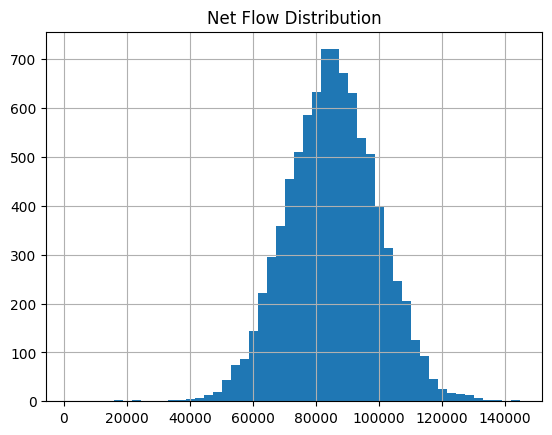

In [100]:
import matplotlib.pyplot as plt

final_df["net_flow"].hist(bins=50)
plt.title("Net Flow Distribution")
plt.show()

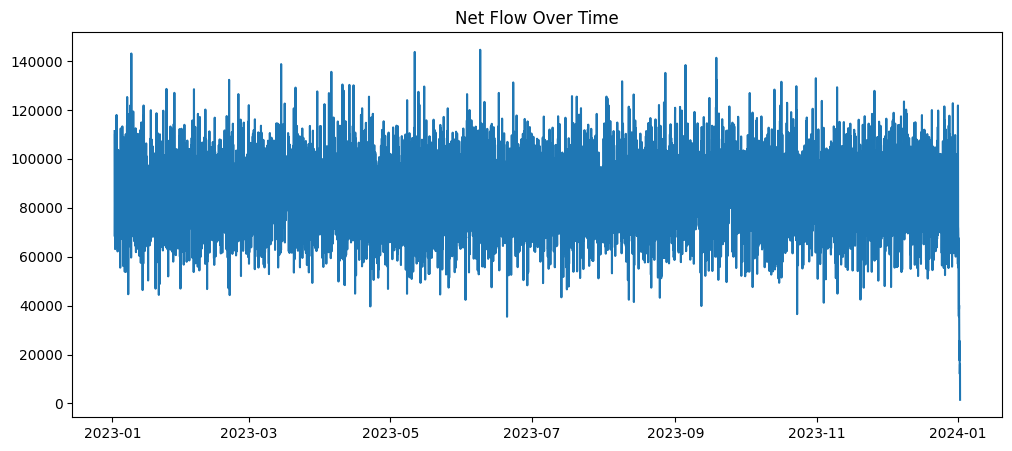

In [101]:
plt.figure(figsize=(12,5))
plt.plot(final_df.index, final_df["net_flow"])
plt.title("Net Flow Over Time")
plt.show()

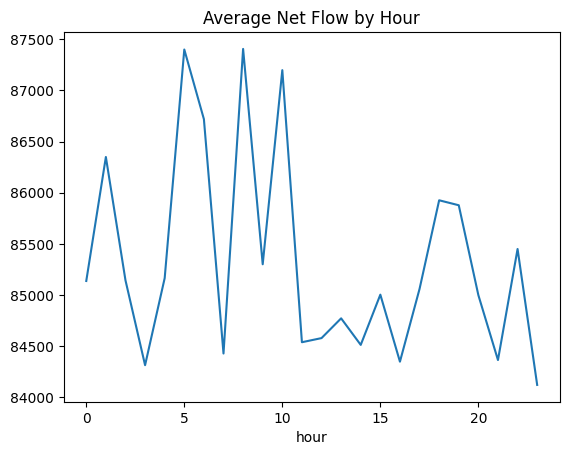

In [102]:
final_df.groupby("hour")["net_flow"].mean().plot()
plt.title("Average Net Flow by Hour")
plt.show()

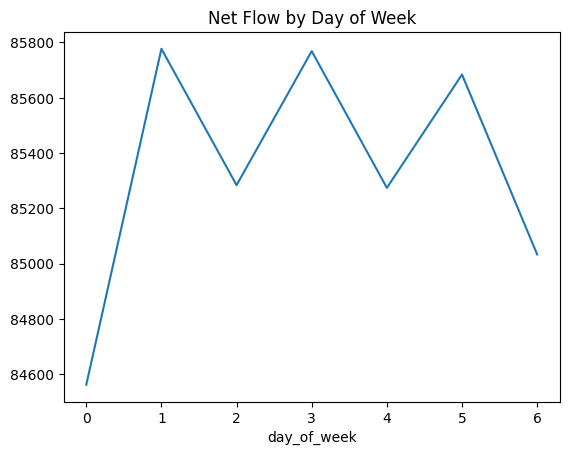

In [103]:
final_df.groupby("day_of_week")["net_flow"].mean().plot()
plt.title("Net Flow by Day of Week")
plt.show()

In [104]:
final_df.groupby("is_weekend")["net_flow"].mean()

is_weekend
0    85330.156858
1    85358.449511
Name: net_flow, dtype: float64


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\phuta\Downloads\ML_Project\ml_project_env\Scripts\python.exe -m pip install --upgrade pip


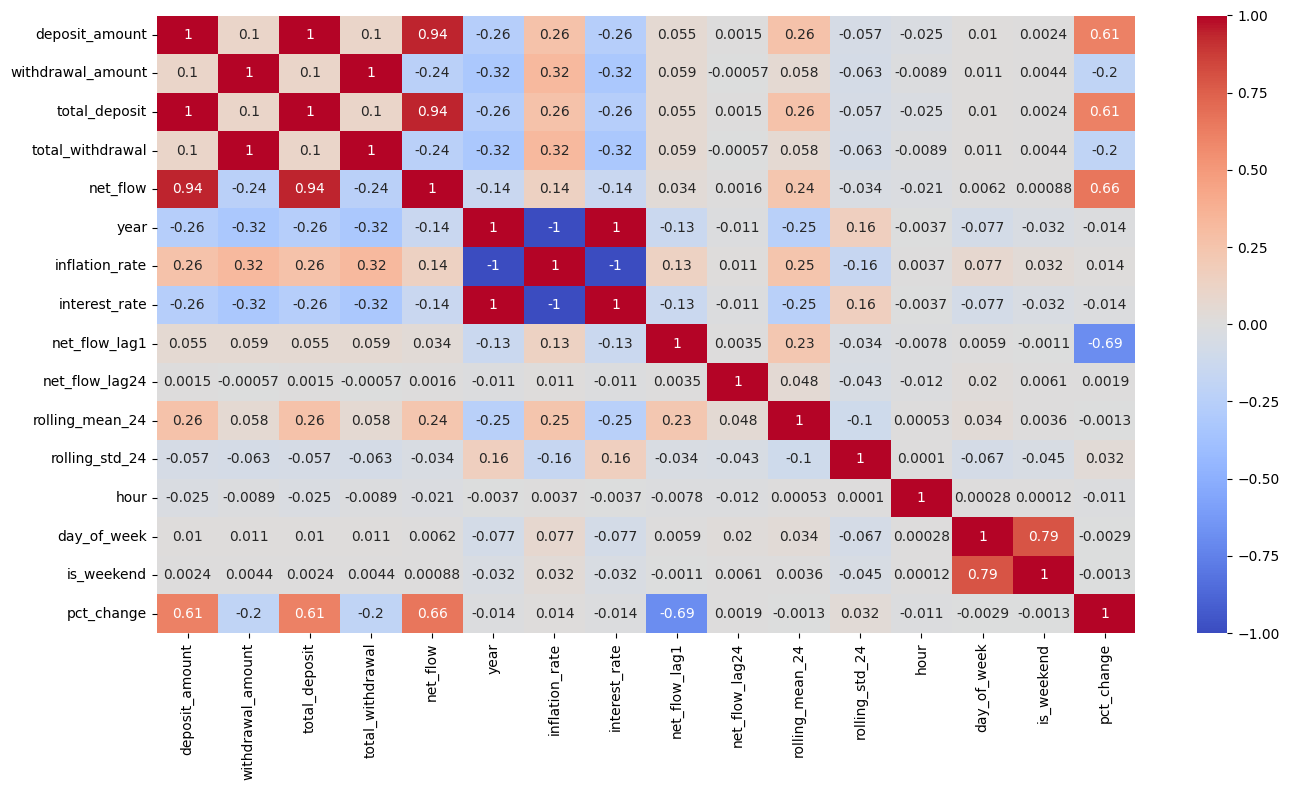

In [105]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn

import seaborn as sns

plt.figure(figsize=(14,8))
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm")
plt.tight_layout()
plt.show()

<Axes: xlabel='net_flow'>

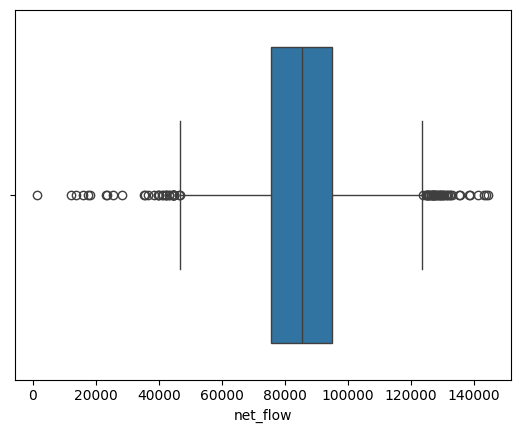

In [106]:
sns.boxplot(x=final_df["net_flow"])

In [107]:
final_df[["net_flow", "inflation_rate", "interest_rate"]].corr()

,net_flow,inflation_rate,interest_rate
net_flow,1.000000,0.143165,-0.143165
inflation_rate,0.143165,1.000000,-1.000000
interest_rate,-0.143165,-1.000000,1.000000


In [108]:
final_df = final_df.drop(columns=[
    "total_deposit",
    "total_withdrawal"
])

In [109]:
final_df

,deposit_amount,withdrawal_amount,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
date,,,,,,,,,,,,,,
2023-01-02 00:00:00,167002.70,55594.06,111408.64,2023,5.649143,6.75,90694.04,6792.10,49967.550833,29164.941848,0,0,0,0.228401
2023-01-02 01:00:00,133305.54,49373.15,83932.39,2023,5.649143,6.75,111408.64,5685.17,53227.851667,28361.969124,1,0,0,-0.246626
2023-01-02 02:00:00,133366.97,65055.80,68311.17,2023,5.649143,6.75,83932.39,13733.34,55501.927917,27222.757122,2,0,0,-0.186117
2023-01-02 03:00:00,143536.41,62842.96,80693.45,2023,5.649143,6.75,68311.17,24908.89,57826.284583,26876.384676,3,0,0,0.181263
2023-01-02 04:00:00,165567.14,55344.08,110223.06,2023,5.649143,6.75,80693.45,20485.42,61565.352917,27685.632723,4,0,0,0.365948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,30151.58,11959.83,18191.75,2024,4.953036,7.00,23585.10,74349.09,57208.743333,27495.383034,18,0,0,-0.228676
2024-01-01 19:00:00,20942.61,8862.07,12080.54,2024,4.953036,7.00,18191.75,68449.77,54860.025417,28866.792012,19,0,0,-0.335933
2024-01-01 20:00:00,22384.81,8801.94,13582.87,2024,4.953036,7.00,12080.54,74112.47,52337.958750,29742.515254,20,0,0,0.124360


In [110]:
final_df["pct_change"] = final_df["pct_change"].replace([float("inf"), -float("inf")], 0)

In [111]:
final_df

,deposit_amount,withdrawal_amount,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
date,,,,,,,,,,,,,,
2023-01-02 00:00:00,167002.70,55594.06,111408.64,2023,5.649143,6.75,90694.04,6792.10,49967.550833,29164.941848,0,0,0,0.228401
2023-01-02 01:00:00,133305.54,49373.15,83932.39,2023,5.649143,6.75,111408.64,5685.17,53227.851667,28361.969124,1,0,0,-0.246626
2023-01-02 02:00:00,133366.97,65055.80,68311.17,2023,5.649143,6.75,83932.39,13733.34,55501.927917,27222.757122,2,0,0,-0.186117
2023-01-02 03:00:00,143536.41,62842.96,80693.45,2023,5.649143,6.75,68311.17,24908.89,57826.284583,26876.384676,3,0,0,0.181263
2023-01-02 04:00:00,165567.14,55344.08,110223.06,2023,5.649143,6.75,80693.45,20485.42,61565.352917,27685.632723,4,0,0,0.365948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,30151.58,11959.83,18191.75,2024,4.953036,7.00,23585.10,74349.09,57208.743333,27495.383034,18,0,0,-0.228676
2024-01-01 19:00:00,20942.61,8862.07,12080.54,2024,4.953036,7.00,18191.75,68449.77,54860.025417,28866.792012,19,0,0,-0.335933
2024-01-01 20:00:00,22384.81,8801.94,13582.87,2024,4.953036,7.00,12080.54,74112.47,52337.958750,29742.515254,20,0,0,0.124360


In [112]:
final_df.isnull().sum()

deposit_amount       0
withdrawal_amount    0
net_flow             0
year                 0
inflation_rate       0
interest_rate        0
net_flow_lag1        0
net_flow_lag24       0
rolling_mean_24      0
rolling_std_24       0
hour                 0
day_of_week          0
is_weekend           0
pct_change           0
dtype: int64

In [113]:
df_insights = final_df.copy()   
df_model = final_df.copy()      

In [118]:
df_model

,deposit_amount,withdrawal_amount,net_flow,year,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
date,,,,,,,,,,,,,,
2023-01-02 00:00:00,167002.70,55594.06,111408.64,2023,5.649143,6.75,90694.04,6792.10,49967.550833,29164.941848,0,0,0,0.228401
2023-01-02 01:00:00,133305.54,49373.15,83932.39,2023,5.649143,6.75,111408.64,5685.17,53227.851667,28361.969124,1,0,0,-0.246626
2023-01-02 02:00:00,133366.97,65055.80,68311.17,2023,5.649143,6.75,83932.39,13733.34,55501.927917,27222.757122,2,0,0,-0.186117
2023-01-02 03:00:00,143536.41,62842.96,80693.45,2023,5.649143,6.75,68311.17,24908.89,57826.284583,26876.384676,3,0,0,0.181263
2023-01-02 04:00:00,165567.14,55344.08,110223.06,2023,5.649143,6.75,80693.45,20485.42,61565.352917,27685.632723,4,0,0,0.365948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,30151.58,11959.83,18191.75,2024,4.953036,7.00,23585.10,74349.09,57208.743333,27495.383034,18,0,0,-0.228676
2024-01-01 19:00:00,20942.61,8862.07,12080.54,2024,4.953036,7.00,18191.75,68449.77,54860.025417,28866.792012,19,0,0,-0.335933
2024-01-01 20:00:00,22384.81,8801.94,13582.87,2024,4.953036,7.00,12080.54,74112.47,52337.958750,29742.515254,20,0,0,0.124360


In [120]:
df_model.columns

Index(['deposit_amount', 'withdrawal_amount', 'net_flow', 'year',
       'inflation_rate', 'interest_rate', 'net_flow_lag1', 'net_flow_lag24',
       'rolling_mean_24', 'rolling_std_24', 'hour', 'day_of_week',
       'is_weekend', 'pct_change'],
      dtype='str')

In [121]:
df_model = df_model.drop(columns=["year"])

In [122]:
df_model.isnull().sum()

deposit_amount       0
withdrawal_amount    0
net_flow             0
inflation_rate       0
interest_rate        0
net_flow_lag1        0
net_flow_lag24       0
rolling_mean_24      0
rolling_std_24       0
hour                 0
day_of_week          0
is_weekend           0
pct_change           0
dtype: int64

In [123]:
features = [
    "net_flow",
    "deposit_amount",
    "withdrawal_amount",
    "net_flow_lag1",
    "net_flow_lag24",
    "rolling_mean_24",
    "rolling_std_24",
    "pct_change",
    "hour",
    "day_of_week",
    "is_weekend",
    "inflation_rate",
    "interest_rate"
]

In [124]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_model[features] = scaler.fit_transform(df_model[features])

In [125]:
df_model

,deposit_amount,withdrawal_amount,net_flow,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
date,,,,,,,,,,,,,
2023-01-02 00:00:00,1.691533,-0.449184,1.803498,0.051311,-0.051311,0.370510,-5.438331,-11.018559,6.914195,-1.661302,-1.493623,-0.631293,0.783068
2023-01-02 01:00:00,-0.697036,-1.715413,-0.097252,0.051311,-0.051311,1.806253,-5.514972,-10.004078,6.545258,-1.516825,-1.493623,-0.631293,-1.087474
2023-01-02 02:00:00,-0.692682,1.476695,-1.177896,0.051311,-0.051311,-0.098145,-4.957739,-9.296472,6.021831,-1.372347,-1.493623,-0.631293,-0.849204
2023-01-02 03:00:00,0.028163,1.026285,-0.321316,0.051311,-0.051311,-1.180863,-4.183976,-8.573222,5.862685,-1.227869,-1.493623,-0.631293,0.597450
2023-01-02 04:00:00,1.589776,-0.500066,1.721482,0.051311,-0.051311,-0.322638,-4.490244,-7.409767,6.234506,-1.083392,-1.493623,-0.631293,1.324696
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,-8.008939,-9.330668,-4.645055,-19.489127,19.489127,-4.280857,-0.760876,-8.765377,6.147093,0.939294,-1.493623,-0.631293,-1.016793
2024-01-01 19:00:00,-8.661703,-9.961198,-5.067816,-19.489127,19.489127,-4.654674,-1.169328,-9.496208,6.777206,1.083771,-1.493623,-0.631293,-1.439145
2024-01-01 20:00:00,-8.559474,-9.973438,-4.963888,-19.489127,19.489127,-5.078246,-0.777259,-10.280979,7.179569,1.228249,-1.493623,-0.631293,0.373378


In [126]:
X = df_model.copy()

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

In [128]:
X_train

,deposit_amount,withdrawal_amount,net_flow,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
date,,,,,,,,,,,,,
2023-01-02 00:00:00,1.691533,-0.449184,1.803498,0.051311,-0.051311,0.370510,-5.438331,-11.018559,6.914195,-1.661302,-1.493623,-0.631293,0.783068
2023-01-02 01:00:00,-0.697036,-1.715413,-0.097252,0.051311,-0.051311,1.806253,-5.514972,-10.004078,6.545258,-1.516825,-1.493623,-0.631293,-1.087474
2023-01-02 02:00:00,-0.692682,1.476695,-1.177896,0.051311,-0.051311,-0.098145,-4.957739,-9.296472,6.021831,-1.372347,-1.493623,-0.631293,-0.849204
2023-01-02 03:00:00,0.028163,1.026285,-0.321316,0.051311,-0.051311,-1.180863,-4.183976,-8.573222,5.862685,-1.227869,-1.493623,-0.631293,0.597450
2023-01-02 04:00:00,1.589776,-0.500066,1.721482,0.051311,-0.051311,-0.322638,-4.490244,-7.409767,6.234506,-1.083392,-1.493623,-0.631293,1.324696
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-10-20 18:00:00,0.362565,1.432274,-0.132942,0.051311,-0.051311,-1.297670,-1.152473,0.604273,-0.707674,0.939294,0.503118,-0.631293,0.876047
2023-10-20 19:00:00,0.610970,-1.136772,0.982622,0.051311,-0.051311,-0.133903,-0.264057,0.837875,-0.627023,1.083771,0.503118,-0.631293,0.644925
2023-10-20 20:00:00,-0.174927,0.241982,-0.252960,0.051311,-0.051311,0.983802,-0.278374,0.842590,-0.630772,1.228249,0.503118,-0.631293,-0.822874


In [129]:
X_test

,deposit_amount,withdrawal_amount,net_flow,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change
date,,,,,,,,,,,,,
2023-10-20 23:00:00,-0.489296,-0.317205,-0.369716,0.051311,-0.051311,0.867607,0.371424,0.400143,-1.048515,1.661681,0.503118,-0.631293,-0.835433
2023-10-21 00:00:00,1.846905,-1.580638,2.339676,0.051311,-0.051311,-0.371131,1.229040,0.608488,-0.429354,-1.661302,1.002303,1.584050,1.811636
2023-10-21 01:00:00,0.054454,-0.809040,0.328110,0.051311,-0.051311,2.343459,0.271577,0.619123,-0.426471,-1.516825,1.002303,1.584050,-1.077242
2023-10-21 02:00:00,0.106697,0.483603,-0.060231,0.051311,-0.051311,0.328034,-0.016783,0.610974,-0.424022,-1.372347,1.002303,1.584050,-0.361713
2023-10-21 03:00:00,0.372008,-0.424358,0.507283,0.051311,-0.051311,-0.061053,-0.477777,0.795510,-0.469102,-1.227869,1.002303,1.584050,0.266124
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,-8.008939,-9.330668,-4.645055,-19.489127,19.489127,-4.280857,-0.760876,-8.765377,6.147093,0.939294,-1.493623,-0.631293,-1.016793
2024-01-01 19:00:00,-8.661703,-9.961198,-5.067816,-19.489127,19.489127,-4.654674,-1.169328,-9.496208,6.777206,1.083771,-1.493623,-0.631293,-1.439145
2024-01-01 20:00:00,-8.559474,-9.973438,-4.963888,-19.489127,19.489127,-5.078246,-0.777259,-10.280979,7.179569,1.228249,-1.493623,-0.631293,0.373378


In [130]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,      
    contamination=0.01,    
    random_state=42
)

model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [132]:
features = [
    "deposit_amount",
    "withdrawal_amount",
    "net_flow",
    "net_flow_lag1",
    "net_flow_lag24",
    "rolling_mean_24",
    "rolling_std_24",
    "pct_change",
    "hour",
    "day_of_week",
    "is_weekend",
    "inflation_rate",
    "interest_rate"
]

In [140]:
X_train = df_model.iloc[:split][features]
X_test = df_model.iloc[split:][features]
model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [143]:
X_full = df_model[features]

df_model["anomaly"] = model.predict(X_full)
X_test["anomaly"] = model.predict(X_test)

In [144]:
print(X_train.columns)
print(df_model[features].columns)

Index(['deposit_amount', 'withdrawal_amount', 'net_flow', 'net_flow_lag1',
       'net_flow_lag24', 'rolling_mean_24', 'rolling_std_24', 'pct_change',
       'hour', 'day_of_week', 'is_weekend', 'inflation_rate', 'interest_rate'],
      dtype='str')
Index(['deposit_amount', 'withdrawal_amount', 'net_flow', 'net_flow_lag1',
       'net_flow_lag24', 'rolling_mean_24', 'rolling_std_24', 'pct_change',
       'hour', 'day_of_week', 'is_weekend', 'inflation_rate', 'interest_rate'],
      dtype='str')


In [137]:
df_model[["anomaly"]]

,anomaly
date,
2023-01-02 00:00:00,-1
2023-01-02 01:00:00,-1
2023-01-02 02:00:00,-1
2023-01-02 03:00:00,-1
2023-01-02 04:00:00,-1
...,...
2024-01-01 18:00:00,-1
2024-01-01 19:00:00,-1
2024-01-01 20:00:00,-1


In [139]:
df_model["anomaly"].value_counts()

anomaly
 1    8659
-1     100
Name: count, dtype: int64

In [145]:
X_test[["anomaly"]]

,anomaly
date,
2023-10-20 23:00:00,1
2023-10-21 00:00:00,1
2023-10-21 01:00:00,1
2023-10-21 02:00:00,1
2023-10-21 03:00:00,1
...,...
2024-01-01 18:00:00,-1
2024-01-01 19:00:00,-1
2024-01-01 20:00:00,-1


In [146]:
X_test["anomaly"].value_counts()

anomaly
 1    1723
-1      29
Name: count, dtype: int64

In [147]:
df_model["anomaly"] = df_model["anomaly"].map({1: 0, -1: 1})

In [148]:
df_model["anomaly"].value_counts()

anomaly
0    8659
1     100
Name: count, dtype: int64

In [150]:
df_model.describe()

,deposit_amount,withdrawal_amount,net_flow,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change,anomaly
count,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8.759000e+03,8759.000000
mean,-7.511846e-16,1.812253e-15,-1.344182e-15,2.518659e-14,4.578494e-15,8.606985e-16,3.082615e-17,-1.437472e-15,3.244858e-17,-2.474204e-17,1.135700e-16,-6.084108e-17,3.184017e-17,0.011417
std,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,1.000057e+00,0.106244
min,-9.903928e+00,-1.137093e+01,-5.801034e+00,-1.948913e+01,-5.131066e-02,-5.078246e+00,-5.514972e+00,-1.240675e+01,-3.390637e+00,-1.661302e+00,-1.493623e+00,-6.312932e-01,-3.689761e+00,0.000000
25%,-6.483969e-01,-6.204759e-01,-6.723024e-01,5.131066e-02,-5.131066e-02,-6.740718e-01,-6.723608e-01,-6.096885e-01,-6.677154e-01,-8.666756e-01,-9.944382e-01,-6.312932e-01,-6.902377e-01,0.000000
50%,1.692888e-03,-3.415534e-04,5.792322e-03,5.131066e-02,-5.131066e-02,5.226408e-03,5.906657e-03,9.891977e-03,-3.786332e-02,-7.204908e-02,3.932388e-03,-6.312932e-01,-1.171178e-01,0.000000
75%,6.586675e-01,6.347034e-01,6.603444e-01,5.131066e-02,-5.131066e-02,6.609056e-01,6.608904e-01,6.303230e-01,6.036710e-01,7.948162e-01,1.002303e+00,1.584050e+00,5.665483e-01,0.000000
max,4.168096e+00,3.727202e+00,4.103449e+00,5.131066e-02,1.948913e+01,4.110617e+00,4.106943e+00,3.408138e+00,7.183478e+00,1.661681e+00,1.501488e+00,1.584050e+00,6.840755e+00,1.000000


In [151]:
df_model[df_model["anomaly"] == 1].sort_values(by="net_flow")

,deposit_amount,withdrawal_amount,net_flow,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change,anomaly
date,,,,,,,,,,,,,,
2024-01-01 22:00:00,-9.903928,-11.370926,-5.801034,-19.489127,19.489127,-4.805677,0.728452,-12.406747,7.107339,1.517204,-1.493623,-0.631293,-3.689761,1
2024-01-01 19:00:00,-8.661703,-9.961198,-5.067816,-19.489127,19.489127,-4.654674,-1.169328,-9.496208,6.777206,1.083771,-1.493623,-0.631293,-1.439145,1
2024-01-01 20:00:00,-8.559474,-9.973438,-4.963888,-19.489127,19.489127,-5.078246,-0.777259,-10.280979,7.179569,1.228249,-1.493623,-0.631293,0.373378,1
2024-01-01 21:00:00,-8.732585,-10.965191,-4.795768,-19.489127,19.489127,-4.974119,0.017845,-11.183128,7.183478,1.372726,-1.493623,-0.631293,0.588225,1
2024-01-01 16:00:00,-7.730537,-8.423051,-4.681820,-19.489127,19.489127,-4.140184,-0.384198,-7.526816,5.122417,0.650339,-1.493623,-0.631293,-1.339156,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-18 15:00:00,2.898689,-1.296131,3.269459,0.051311,-0.051311,1.130990,-1.242665,1.591065,2.210226,0.505861,-1.493623,-0.631293,1.081813,1
2023-09-05 10:00:00,2.976734,-2.253602,3.671039,0.051311,-0.051311,-0.666086,-0.718968,1.734523,0.137615,-0.216527,-0.994438,-0.631293,3.141823,1
2023-03-14 21:00:00,3.390095,-1.144892,3.697640,0.051311,-0.051311,-1.563740,0.010103,0.774012,1.414048,1.372726,-0.994438,-0.631293,4.650245,1


In [152]:
df_model

,deposit_amount,withdrawal_amount,net_flow,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change,anomaly
date,,,,,,,,,,,,,,
2023-01-02 00:00:00,1.691533,-0.449184,1.803498,0.051311,-0.051311,0.370510,-5.438331,-11.018559,6.914195,-1.661302,-1.493623,-0.631293,0.783068,1
2023-01-02 01:00:00,-0.697036,-1.715413,-0.097252,0.051311,-0.051311,1.806253,-5.514972,-10.004078,6.545258,-1.516825,-1.493623,-0.631293,-1.087474,1
2023-01-02 02:00:00,-0.692682,1.476695,-1.177896,0.051311,-0.051311,-0.098145,-4.957739,-9.296472,6.021831,-1.372347,-1.493623,-0.631293,-0.849204,1
2023-01-02 03:00:00,0.028163,1.026285,-0.321316,0.051311,-0.051311,-1.180863,-4.183976,-8.573222,5.862685,-1.227869,-1.493623,-0.631293,0.597450,1
2023-01-02 04:00:00,1.589776,-0.500066,1.721482,0.051311,-0.051311,-0.322638,-4.490244,-7.409767,6.234506,-1.083392,-1.493623,-0.631293,1.324696,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,-8.008939,-9.330668,-4.645055,-19.489127,19.489127,-4.280857,-0.760876,-8.765377,6.147093,0.939294,-1.493623,-0.631293,-1.016793,1
2024-01-01 19:00:00,-8.661703,-9.961198,-5.067816,-19.489127,19.489127,-4.654674,-1.169328,-9.496208,6.777206,1.083771,-1.493623,-0.631293,-1.439145,1
2024-01-01 20:00:00,-8.559474,-9.973438,-4.963888,-19.489127,19.489127,-5.078246,-0.777259,-10.280979,7.179569,1.228249,-1.493623,-0.631293,0.373378,1


In [153]:
df_model[df_model["anomaly"] == 1]["net_flow"].describe()

count    100.000000
mean      -0.883905
std        2.513987
min       -5.801034
25%       -2.721668
50%       -1.948054
75%        1.423976
max        4.103449
Name: net_flow, dtype: float64

In [154]:
df_model[df_model["anomaly"] == 0]["net_flow"].describe()

count    8659.000000
mean        0.010208
std         0.964505
min        -3.451369
25%        -0.659268
50%         0.007925
75%         0.656669
max         4.042115
Name: net_flow, dtype: float64

In [155]:
df_model[df_model["anomaly"] == 1][["net_flow","pct_change","hour"]]

,net_flow,pct_change,hour
date,,,
2023-01-02 00:00:00,1.803498,0.783068,-1.661302
2023-01-02 01:00:00,-0.097252,-1.087474,-1.516825
2023-01-02 02:00:00,-1.177896,-0.849204,-1.372347
2023-01-02 03:00:00,-0.321316,0.597450,-1.227869
2023-01-02 04:00:00,1.721482,1.324696,-1.083392
...,...,...,...
2024-01-01 18:00:00,-4.645055,-1.016793,0.939294
2024-01-01 19:00:00,-5.067816,-1.439145,1.083771
2024-01-01 20:00:00,-4.963888,0.373378,1.228249


In [156]:
df_model["score"] = model.decision_function(df_model[features])

In [157]:
df_model

,deposit_amount,withdrawal_amount,net_flow,inflation_rate,interest_rate,net_flow_lag1,net_flow_lag24,rolling_mean_24,rolling_std_24,hour,day_of_week,is_weekend,pct_change,anomaly,score
date,,,,,,,,,,,,,,,
2023-01-02 00:00:00,1.691533,-0.449184,1.803498,0.051311,-0.051311,0.370510,-5.438331,-11.018559,6.914195,-1.661302,-1.493623,-0.631293,0.783068,1,-0.045492
2023-01-02 01:00:00,-0.697036,-1.715413,-0.097252,0.051311,-0.051311,1.806253,-5.514972,-10.004078,6.545258,-1.516825,-1.493623,-0.631293,-1.087474,1,-0.046355
2023-01-02 02:00:00,-0.692682,1.476695,-1.177896,0.051311,-0.051311,-0.098145,-4.957739,-9.296472,6.021831,-1.372347,-1.493623,-0.631293,-0.849204,1,-0.033798
2023-01-02 03:00:00,0.028163,1.026285,-0.321316,0.051311,-0.051311,-1.180863,-4.183976,-8.573222,5.862685,-1.227869,-1.493623,-0.631293,0.597450,1,-0.029231
2023-01-02 04:00:00,1.589776,-0.500066,1.721482,0.051311,-0.051311,-0.322638,-4.490244,-7.409767,6.234506,-1.083392,-1.493623,-0.631293,1.324696,1,-0.031810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 18:00:00,-8.008939,-9.330668,-4.645055,-19.489127,19.489127,-4.280857,-0.760876,-8.765377,6.147093,0.939294,-1.493623,-0.631293,-1.016793,1,-0.104078
2024-01-01 19:00:00,-8.661703,-9.961198,-5.067816,-19.489127,19.489127,-4.654674,-1.169328,-9.496208,6.777206,1.083771,-1.493623,-0.631293,-1.439145,1,-0.116476
2024-01-01 20:00:00,-8.559474,-9.973438,-4.963888,-19.489127,19.489127,-5.078246,-0.777259,-10.280979,7.179569,1.228249,-1.493623,-0.631293,0.373378,1,-0.100324


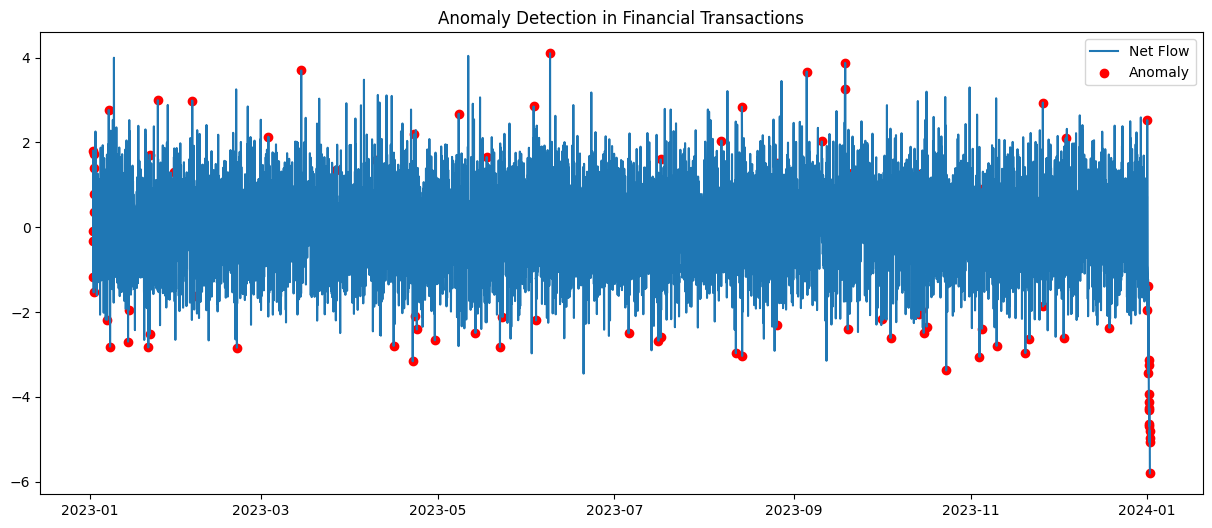

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df_model.index, df_model["net_flow"], label="Net Flow")

plt.scatter(
    df_model[df_model["anomaly"] == 1].index,
    df_model[df_model["anomaly"] == 1]["net_flow"],
    color="red",
    label="Anomaly"
)

plt.legend()
plt.title("Anomaly Detection in Financial Transactions")
plt.show()

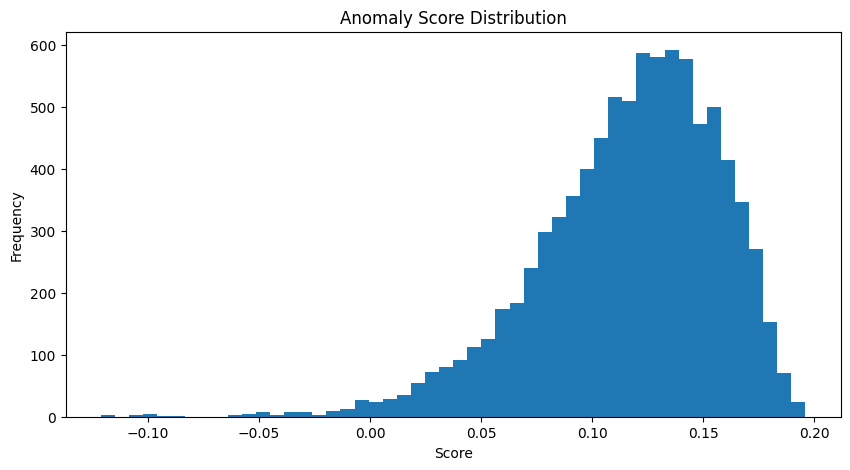

In [160]:
plt.figure(figsize=(10,5))

plt.hist(df_model["score"], bins=50)

plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

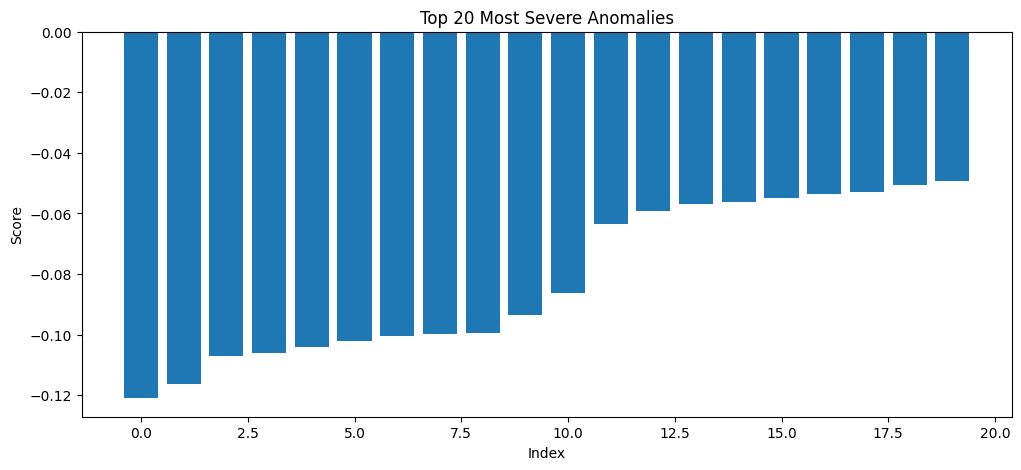

In [161]:
top_anomalies = df_model.sort_values(by="score").head(20)

plt.figure(figsize=(12,5))
plt.bar(range(len(top_anomalies)), top_anomalies["score"])
plt.title("Top 20 Most Severe Anomalies")
plt.xlabel("Index")
plt.ylabel("Score")
plt.show()

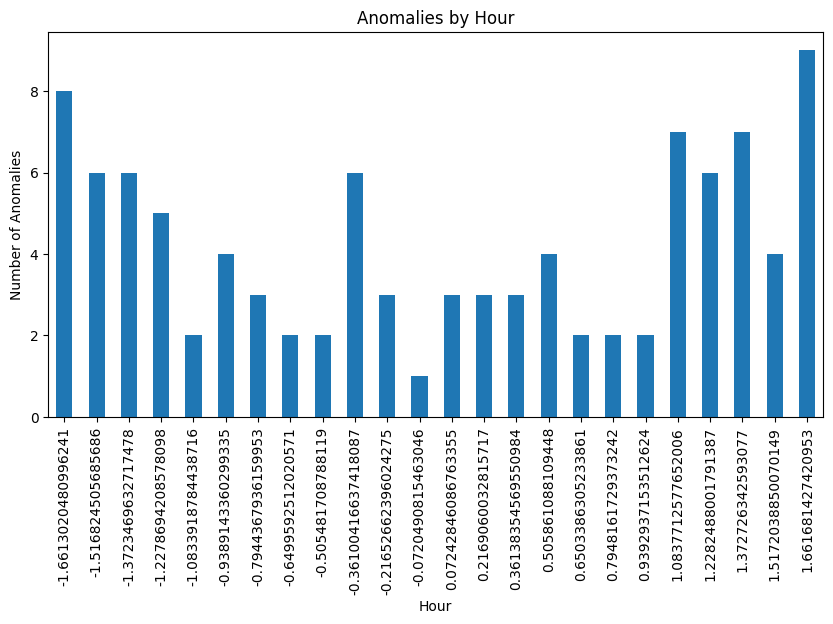

In [162]:
hour_anomaly = df_model.groupby("hour")["anomaly"].sum()

plt.figure(figsize=(10,5))
hour_anomaly.plot(kind="bar")

plt.title("Anomalies by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Anomalies")
plt.show()

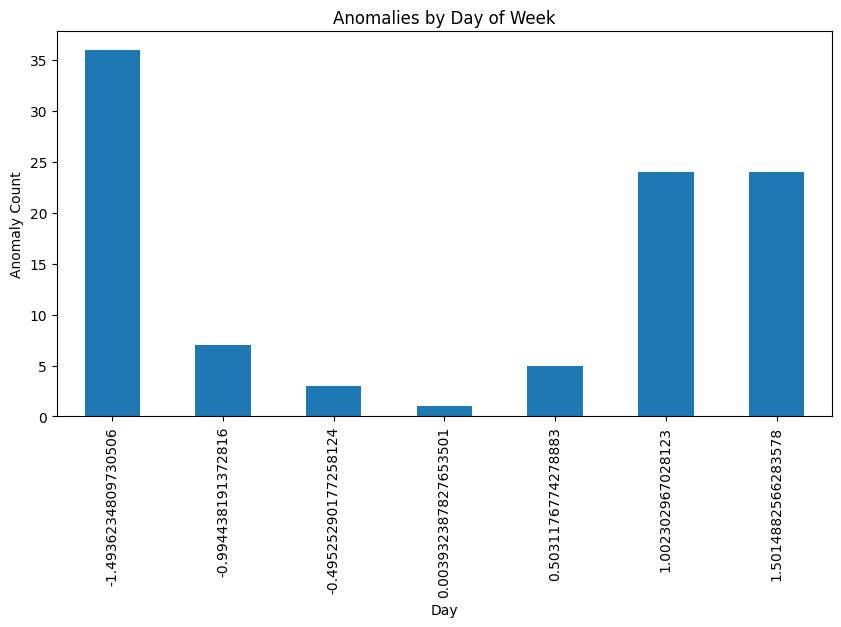

In [163]:
dow_anomaly = df_model.groupby("day_of_week")["anomaly"].sum()

plt.figure(figsize=(10,5))
dow_anomaly.plot(kind="bar")

plt.title("Anomalies by Day of Week")
plt.xlabel("Day")
plt.ylabel("Anomaly Count")
plt.show()

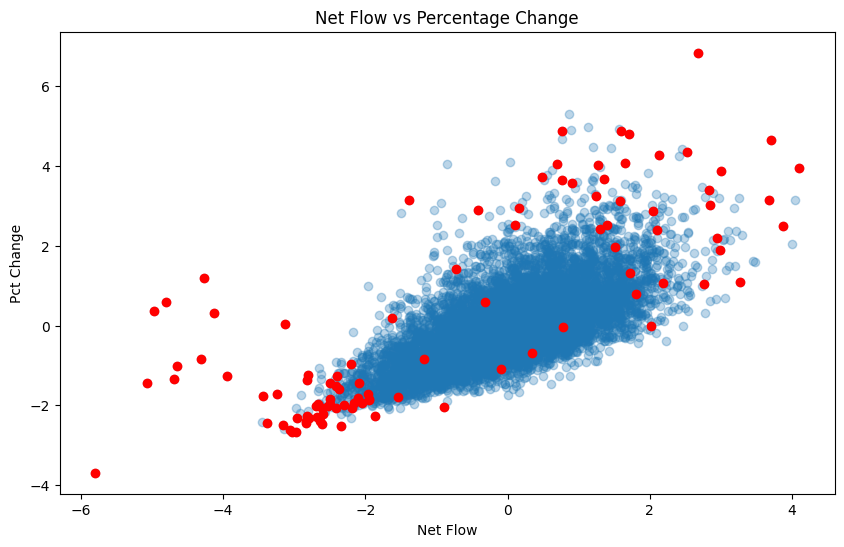

In [164]:
plt.figure(figsize=(10,6))

plt.scatter(df_model["net_flow"], df_model["pct_change"], alpha=0.3)

plt.scatter(
    df_model[df_model["anomaly"] == 1]["net_flow"],
    df_model[df_model["anomaly"] == 1]["pct_change"],
    color="red"
)

plt.title("Net Flow vs Percentage Change")
plt.xlabel("Net Flow")
plt.ylabel("Pct Change")
plt.show()

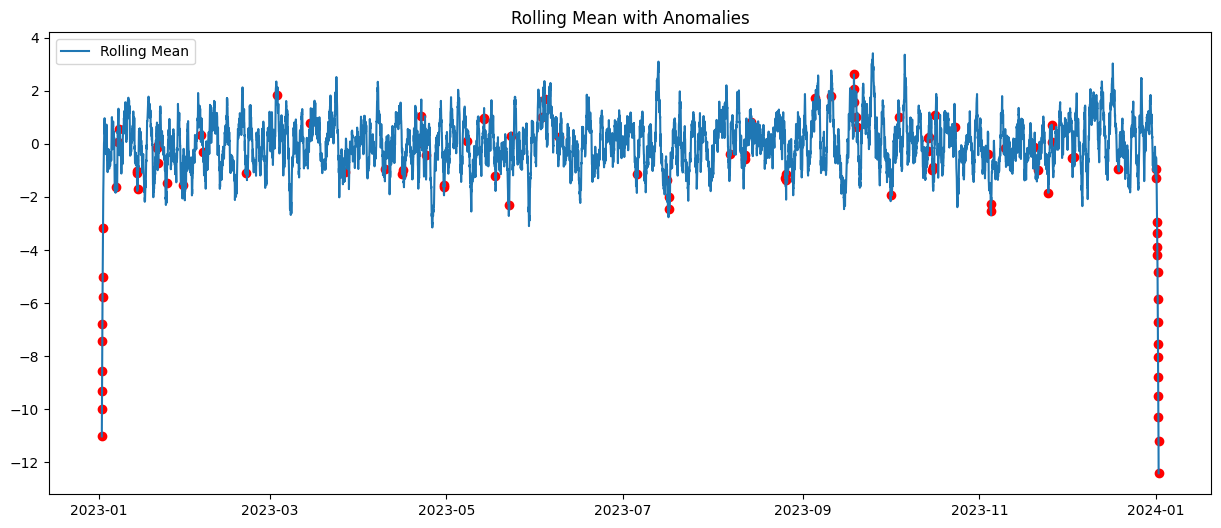

In [165]:
plt.figure(figsize=(15,6))

plt.plot(df_model.index, df_model["rolling_mean_24"], label="Rolling Mean")

plt.scatter(
    df_model[df_model["anomaly"] == 1].index,
    df_model[df_model["anomaly"] == 1]["rolling_mean_24"],
    color="red"
)

plt.title("Rolling Mean with Anomalies")
plt.legend()
plt.show()

In [ ]:
df_model.to_csv("processed_data